In [15]:
import numpy as np
import json
import torch
import torch.nn as nn
from pathlib import Path
from matplotlib import pyplot as plt

In [16]:
from src.utils.schedulers import WarmupInvRsqrtLR, WarmupCosineDecayLR, WarmupCosineAnnealingLR, WarmupCosineAnnealingWarmRestarts
from src.models.model_utilizer import update_optimizer_simple

In [17]:
config_dir = Path("./src/config/")

model_config_path = config_dir / "base-model-config.json"
assert model_config_path.exists(), f"Config not found: {model_config_path}"
with open(model_config_path, "r") as f:
    model_config = json.load(f)

In [18]:
model = nn.Linear(10, 10)

optimizer = update_optimizer_simple(
    net = model,
    optim = model_config['solver_type'],
    lr=model_config['base_lr'],
    decay=model_config['weight_decay']
    )

In [19]:
if bool(model_config['scheduler_on']):
    batch_size = model_config['batch_size']
    train_dataset_size = 36_000
    batch_num = train_dataset_size // batch_size
    warmup_epochs = model_config['scheduler_warmup_epochs']
    
    if model_config['scheduler_mode'] == 'batch':
        warmup_steps = warmup_epochs * batch_num
        total_steps = model_config['epochs'] * batch_num
    elif model_config['scheduler_mode'] == 'epoch':
        warmup_steps = warmup_epochs
        total_steps = model_config['epochs']
    else:
        raise NotImplementedError(f"Scheduler MODE not supported: {model_config['scheduler_mode']}")
    
    #if model_config['scheduler_type'] == "CosineAnnealingLR":
    scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=model_config['scheduler_T_max'],
        eta_min=model_config['scheduler_eta_min']
        )
    #elif model_config['scheduler_type'] == "CosineAnnealingWarmRestarts":
    scheduler2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, 
        T_0=model_config['scheduler_T_0'],
        T_mult=model_config['scheduler_T_mult'],
        eta_min=model_config['scheduler_eta_min']
        )
    #elif model_config['scheduler_type'] == "WarmupInvRsqrtLR":
    scheduler3 = WarmupInvRsqrtLR(
        optimizer,
        lr_max=model_config['base_lr'],
        warmup_steps=warmup_steps
        )
    #elif model_config['scheduler_type'] == "WarmupCosineDecayLR":
    scheduler4 = WarmupCosineDecayLR(
        optimizer,
        lr_max=model_config['base_lr'],
        warmup_steps=warmup_steps,
        decay_rate=1e-4,
        eta_min=model_config['scheduler_eta_min']
        )
    #elif model_config['scheduler_type'] == "WarmupCosineAnnealingLR":
    scheduler5 = WarmupCosineAnnealingLR(
        optimizer,
        lr_max=model_config['base_lr'],
        warmup_steps=warmup_steps,
        total_steps=total_steps,
        eta_min=model_config['scheduler_eta_min']
        )
    #elif model_config['scheduler_type'] == "WarmupCosineAnnealingWarmRestarts":
    scheduler6 = WarmupCosineAnnealingWarmRestarts(
        optimizer,
        lr_max=model_config['base_lr'],
        warmup_steps=warmup_steps,
        T_0=model_config['scheduler_T_0'],
        T_mult=model_config['scheduler_T_mult'],
        eta_min=model_config['scheduler_eta_min']
        )
    #else:
    #    raise NotImplementedError(f"Scheduler not supported: {model_config['scheduler_type']}")

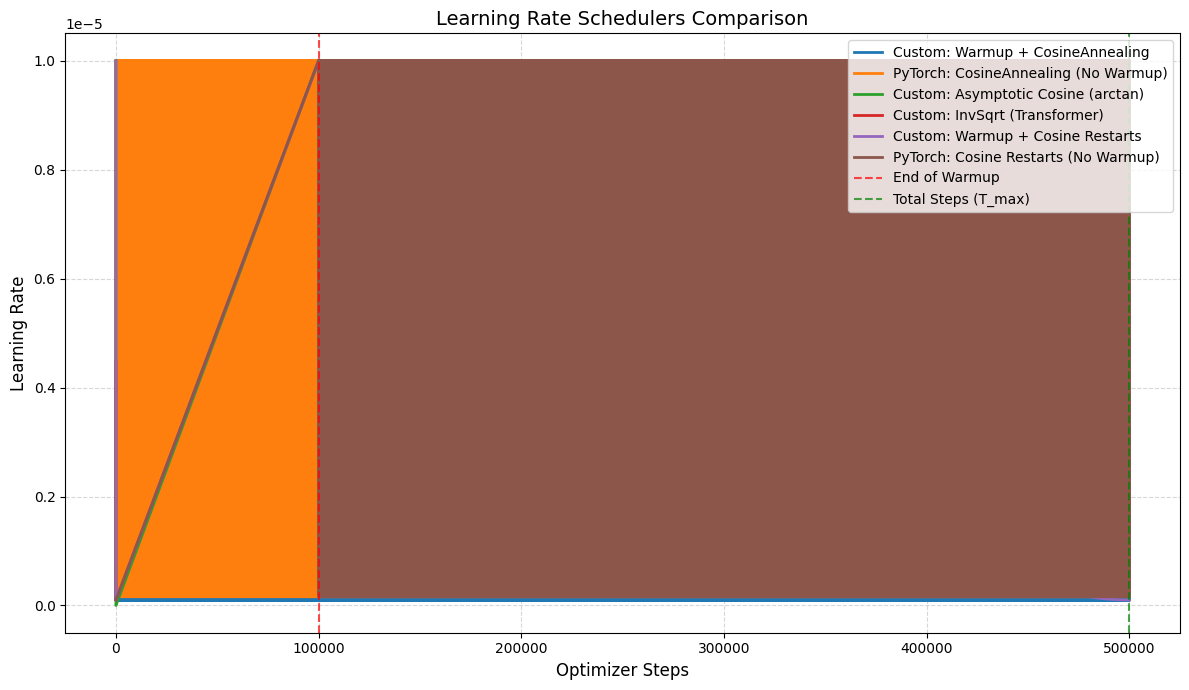

In [ ]:
def plot_lr_schedulers():
    histories = {}
    
    # Вспомогательная функция для сбора истории LR
    def collect_lrs(scheduler, steps):
        for _ in range(steps):
            scheduler.step()
        return lrs

    # 1. Ваш WarmupCosineAnnealingLR
    sched = scheduler1
    histories["Custom: Warmup + CosineAnnealing"] = collect_lrs(sched, total_steps)

    # 2. Встроенный PyTorch CosineAnnealingLR (Обратите внимание: нет прогрева!)
    sched = scheduler2
    histories["PyTorch: CosineAnnealing (No Warmup)"] = collect_lrs(sched, total_steps)

    # 3. Ваш асимптотический WarmupCosineDecayLR
    sched = scheduler3
    histories["Custom: Asymptotic Cosine (arctan)"] = collect_lrs(sched, total_steps)

    # 4. Ваш WarmupInvRsqrtLR (Классический Transformer)
    sched = scheduler4
    histories["Custom: InvSqrt (Transformer)"] = collect_lrs(sched, total_steps)

    # 5. Ваш WarmupCosineAnnealingWarmRestarts
    sched = scheduler5
    histories["Custom: Warmup + Cosine Restarts"] = collect_lrs(sched, total_steps)

    # 6. Встроенный PyTorch CosineAnnealingWarmRestarts (Нет прогрева!)
    sched = scheduler6
    histories["PyTorch: Cosine Restarts (No Warmup)"] = collect_lrs(sched, total_steps)

    # Построение графиков
    plt.figure(figsize=(12, 7))
    for name, lrs in histories.items():
        plt.plot(lrs, label=name, linewidth=2)
        
    plt.axvline(x=warmup_steps, color='r', linestyle='--', alpha=0.7, label='End of Warmup')
    plt.axvline(x=total_steps, color='g', linestyle='--', alpha=0.7, label='Total Steps (T_max)')
    
    plt.title("Learning Rate Schedulers Comparison", fontsize=14)
    plt.xlabel("Optimizer Steps", fontsize=12)
    plt.ylabel("Learning Rate", fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_lr_schedulers()

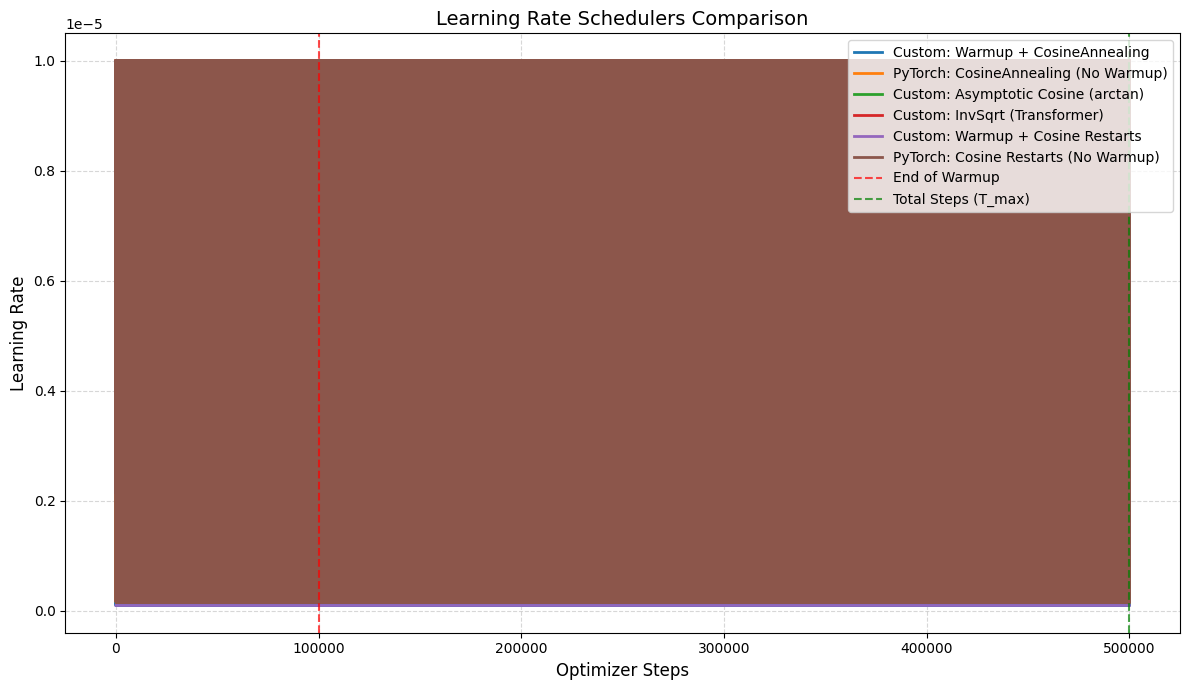

In [22]:
import warnings

# Подавляем warning о порядке вызовов
warnings.filterwarnings("ignore", message=".*Detected call of `lr_scheduler.step\(\)` before `optimizer.step\(\)`.*")

# ... [Здесь должны быть ваши классы планировщиков] ...

def plot_lr_schedulers():
    histories = {}
    
    # 1. Ваш WarmupCosineAnnealingLR
    sched = scheduler1
    lrs = []
    for _ in range(total_steps):
        lrs.append(sched.get_last_lr()[0])
        sched.step()
    histories["Custom: Warmup + CosineAnnealing"] = lrs

    # 2. Встроенный PyTorch CosineAnnealingLR
    sched = scheduler2
    lrs = []
    for _ in range(total_steps):
        lrs.append(sched.get_last_lr()[0])
        sched.step()
    histories["PyTorch: CosineAnnealing (No Warmup)"] = lrs

    # 3. Ваш асимптотический WarmupCosineDecayLR
    sched = scheduler3
    lrs = []
    for _ in range(total_steps):
        lrs.append(sched.get_last_lr()[0])
        sched.step()
    histories["Custom: Asymptotic Cosine (arctan)"] = lrs

    # 4. Ваш WarmupInvRsqrtLR
    sched = scheduler4
    lrs = []
    for _ in range(total_steps):
        lrs.append(sched.get_last_lr()[0])
        sched.step()
    histories["Custom: InvSqrt (Transformer)"] = lrs

    # 5. Ваш WarmupCosineAnnealingWarmRestarts
    sched = scheduler5
    lrs = []
    for _ in range(total_steps):
        lrs.append(sched.get_last_lr()[0])
        sched.step()
    histories["Custom: Warmup + Cosine Restarts"] = lrs

    # 6. Встроенный PyTorch CosineAnnealingWarmRestarts
    sched = scheduler6
    lrs = []
    for _ in range(total_steps):
        lrs.append(sched.get_last_lr()[0])
        sched.step()
    histories["PyTorch: Cosine Restarts (No Warmup)"] = lrs

    # Построение графиков
    plt.figure(figsize=(12, 7))
    for name, lrs in histories.items():
        plt.plot(lrs, label=name, linewidth=2)
        
    plt.axvline(x=warmup_steps, color='r', linestyle='--', alpha=0.7, label='End of Warmup')
    plt.axvline(x=total_steps, color='g', linestyle='--', alpha=0.7, label='Total Steps (T_max)')
    
    plt.title("Learning Rate Schedulers Comparison", fontsize=14)
    plt.xlabel("Optimizer Steps", fontsize=12)
    plt.ylabel("Learning Rate", fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_lr_schedulers()